# UV Index vs Melanoma Cancer Incidence Analysis

This notebook analyzes the relationship between UV radiation exposure and melanoma skin cancer incidence rates for Denmark, Norway, and Sweden.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Load Data

In [5]:
# Load the aggregated data
df = pd.read_csv('data/all_countries_full_aggregation.csv')
print(f"Countries: {df['Country'].tolist()}")
df

Countries: ['Denmark', 'Norway', 'Sweden']


,Country,Total_Cancer_Cases,Avg_Yearly_Cancer_Cases,ALLSKY_SFC_UV_INDEX_mean,ALLSKY_SFC_UV_INDEX_max,ALLSKY_SFC_UV_INDEX_min,ALLSKY_SFC_UV_INDEX_std,ALLSKY_SFC_UVA_mean,ALLSKY_SFC_UVA_max,ALLSKY_SFC_UVA_min,...,UV_End_Date,UV_Total_Days,Std_Yearly_Cancer_Cases,Min_Yearly_Cancer_Cases,Max_Yearly_Cancer_Cases,Cancer_Start_Year,Cancer_End_Year,Cancer_Years_Count,Population,Incidence_Per_100K
0,Denmark,71691.0,885.074074,0.544,2.12,0.0,0.528,0.166,0.466,0.004,...,2023-12-31,15705,888.953300,32.0,3044.0,1943,2023,81,5932000,14.92
1,Norway,63943.0,900.605634,0.520,2.46,0.0,0.526,0.168,0.631,0.003,...,2023-12-31,15705,753.675365,61.0,2950.0,1953,2023,71,5474000,16.45
2,Sweden,113214.0,1768.968750,0.438,1.86,0.0,0.456,0.145,0.464,0.003,...,2023-12-31,15705,1337.639498,236.0,5112.0,1960,2023,64,10540000,16.78


## 1. UV Index vs Cancer Incidence (Bar Chart Comparison)

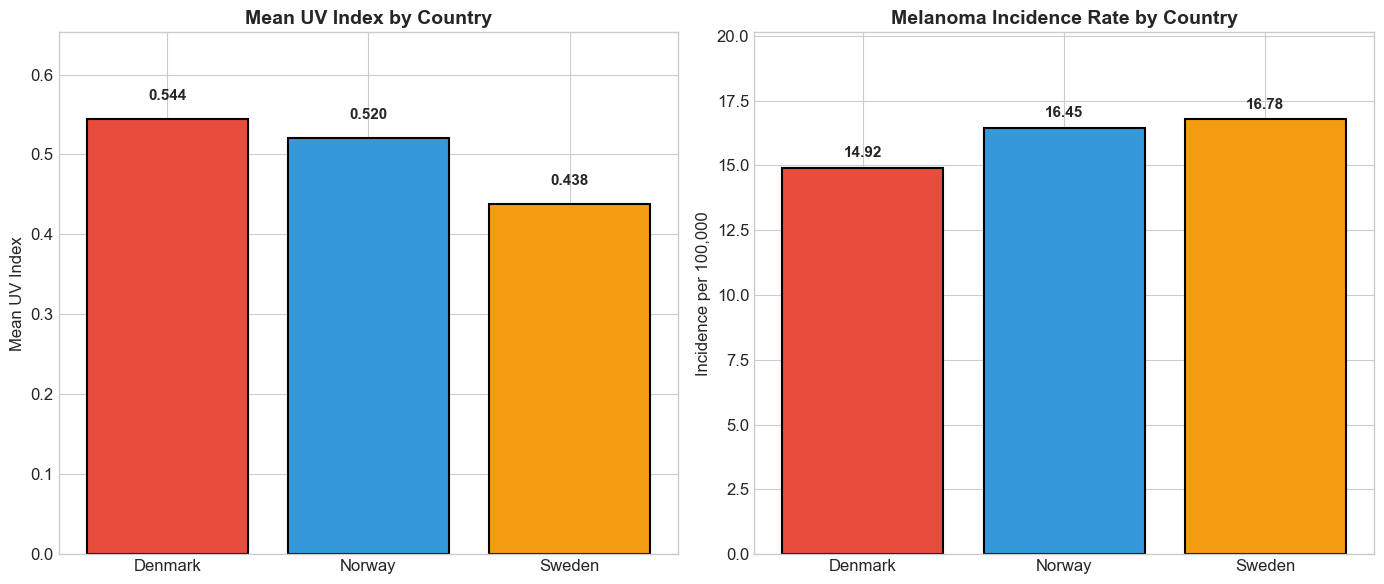

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#E74C3C', '#3498DB', '#F39C12']

# Plot 1: Mean UV Index by Country
bars1 = axes[0].bar(df['Country'], df['ALLSKY_SFC_UV_INDEX_mean'], color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Mean UV Index', fontsize=12)
axes[0].set_title('Mean UV Index by Country', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(df['ALLSKY_SFC_UV_INDEX_mean']) * 1.2)

# Add value labels
for bar, val in zip(bars1, df['ALLSKY_SFC_UV_INDEX_mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Incidence per 100K by Country
bars2 = axes[1].bar(df['Country'], df['Incidence_Per_100K'], color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Incidence per 100,000', fontsize=12)
axes[1].set_title('Melanoma Incidence Rate by Country', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, max(df['Incidence_Per_100K']) * 1.2)

# Add value labels
for bar, val in zip(bars2, df['Incidence_Per_100K']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Scatter Plot: UV Index vs Incidence Rate

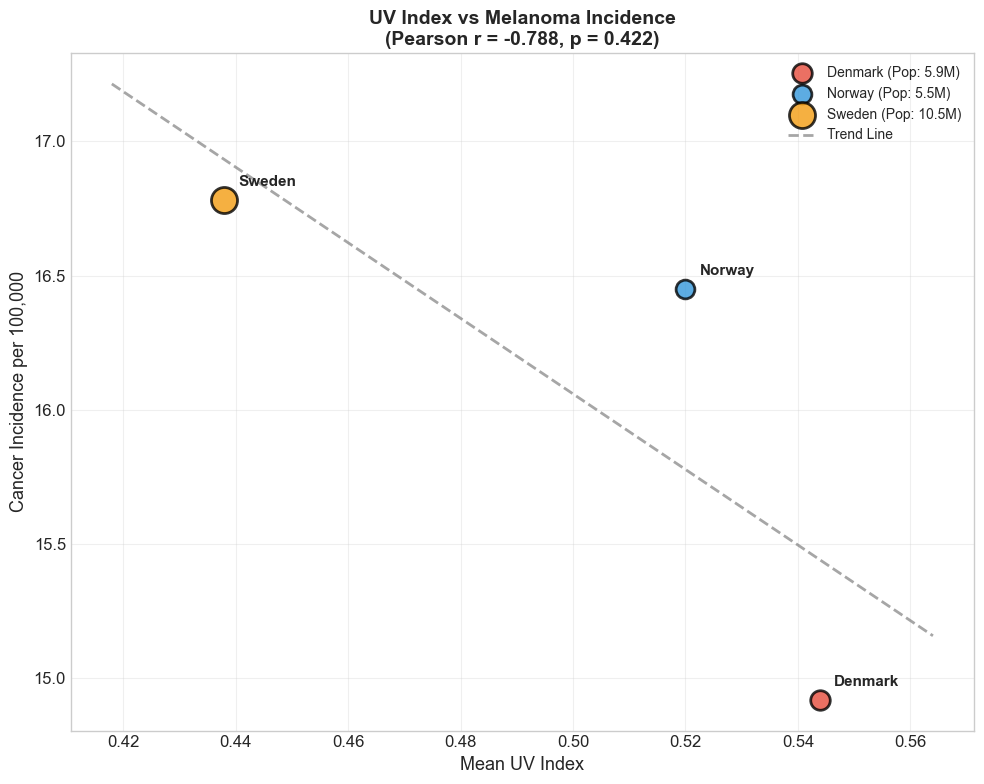

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Denmark': '#E74C3C', 'Norway': '#3498DB', 'Sweden': '#F39C12'}

# Scatter plot
for _, row in df.iterrows():
    ax.scatter(row['ALLSKY_SFC_UV_INDEX_mean'], row['Incidence_Per_100K'], 
               s=row['Population']/30000, c=colors[row['Country']], 
               edgecolors='black', linewidth=2, alpha=0.8,
               label=f"{row['Country']} (Pop: {row['Population']/1e6:.1f}M)")

# Add regression line
x = df['ALLSKY_SFC_UV_INDEX_mean']
y = df['Incidence_Per_100K']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(x.min() - 0.02, x.max() + 0.02, 100)
ax.plot(x_line, p(x_line), '--', color='gray', linewidth=2, alpha=0.7, label='Trend Line')

# Calculate correlation
r, p_val = stats.pearsonr(x, y)

ax.set_xlabel('Mean UV Index', fontsize=13)
ax.set_ylabel('Cancer Incidence per 100,000', fontsize=13)
ax.set_title(f'UV Index vs Melanoma Incidence\n(Pearson r = {r:.3f}, p = {p_val:.3f})', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Add country labels
for _, row in df.iterrows():
    ax.annotate(row['Country'], 
                (row['ALLSKY_SFC_UV_INDEX_mean'], row['Incidence_Per_100K']),
                xytext=(10, 10), textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/scatter_uv_vs_incidence.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Combined UV Parameters Comparison

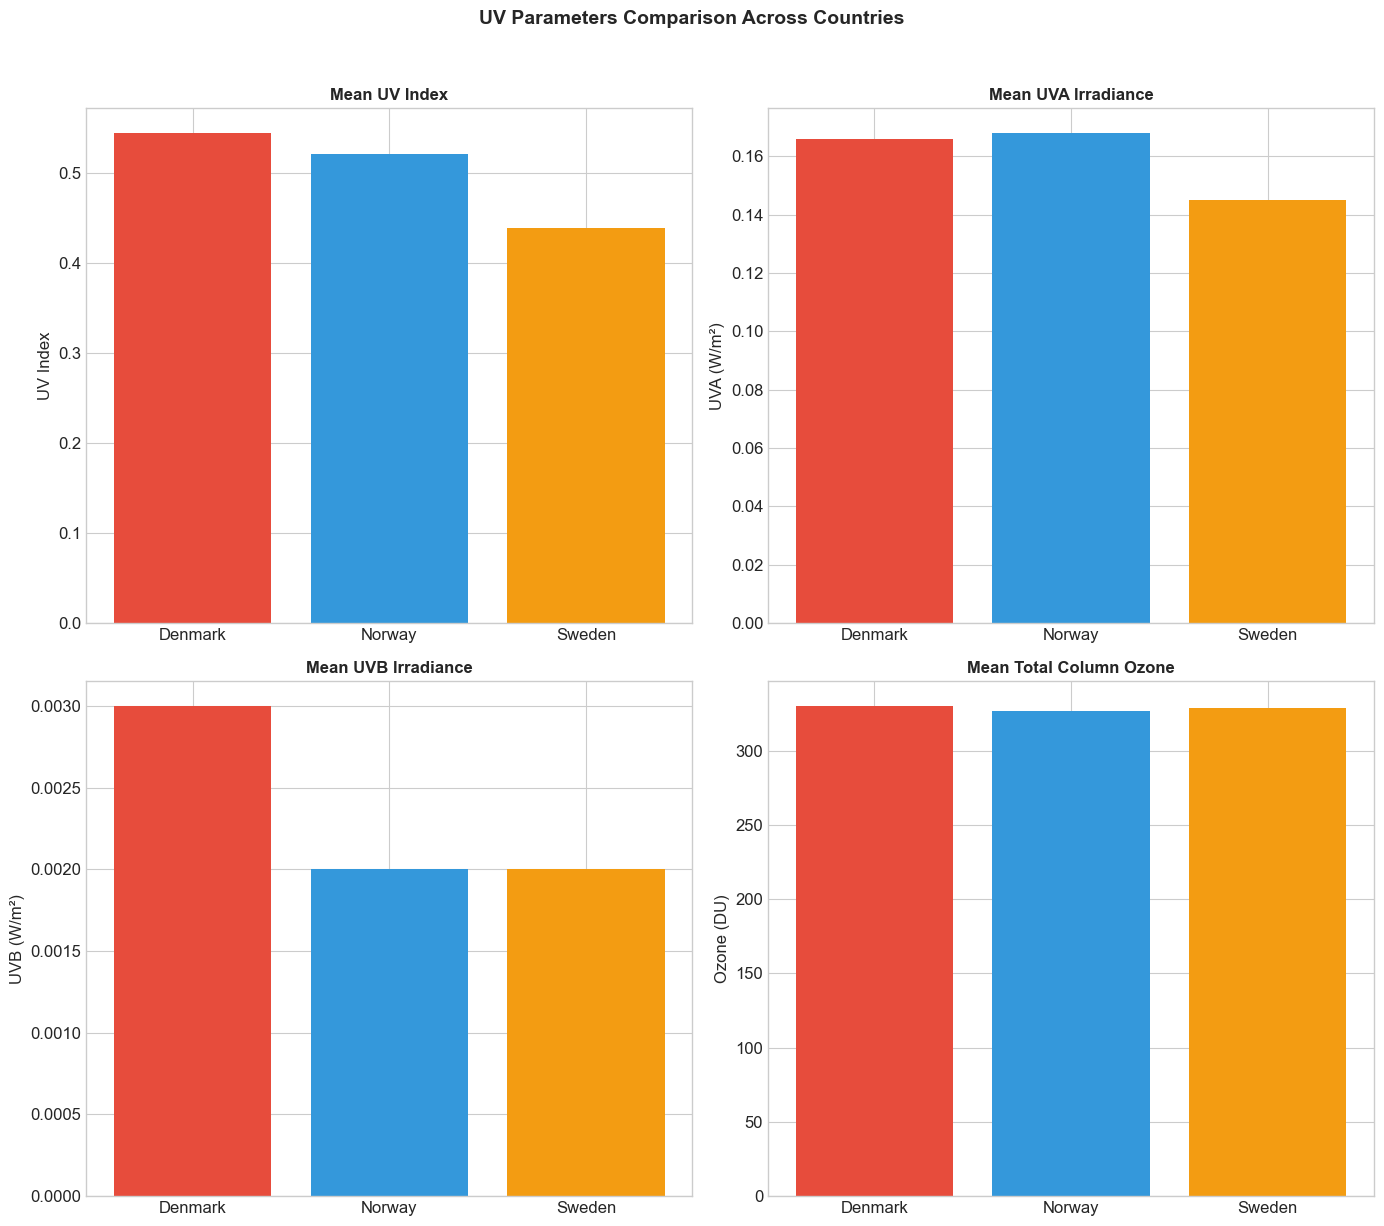

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors = ['#E74C3C', '#3498DB', '#F39C12']

# UV Index
axes[0, 0].bar(df['Country'], df['ALLSKY_SFC_UV_INDEX_mean'], color=colors)
axes[0, 0].set_title('Mean UV Index', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('UV Index')

# UVA
axes[0, 1].bar(df['Country'], df['ALLSKY_SFC_UVA_mean'], color=colors)
axes[0, 1].set_title('Mean UVA Irradiance', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('UVA (W/m²)')

# UVB
axes[1, 0].bar(df['Country'], df['ALLSKY_SFC_UVB_mean'], color=colors)
axes[1, 0].set_title('Mean UVB Irradiance', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('UVB (W/m²)')

# Ozone
axes[1, 1].bar(df['Country'], df['TO3_mean'], color=colors)
axes[1, 1].set_title('Mean Total Column Ozone', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Ozone (DU)')

plt.suptitle('UV Parameters Comparison Across Countries', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/uv_parameters_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Heatmap

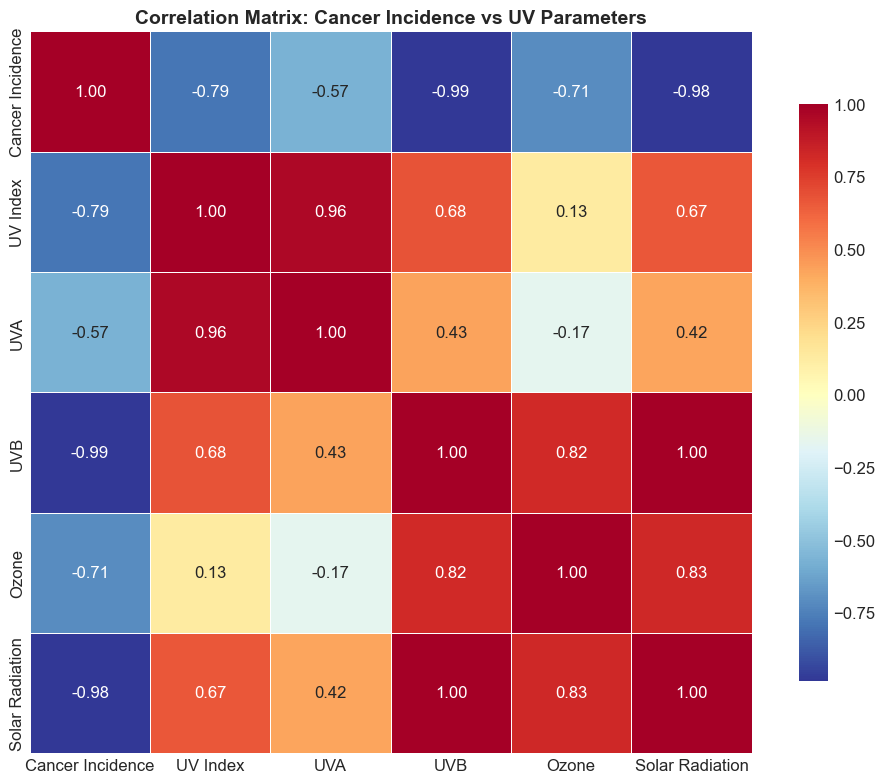

In [9]:
# Select key columns for correlation
key_cols = [
    'Incidence_Per_100K', 
    'ALLSKY_SFC_UV_INDEX_mean', 
    'ALLSKY_SFC_UVA_mean',
    'ALLSKY_SFC_UVB_mean',
    'TO3_mean',
    'ALLSKY_SFC_SW_DWN_mean'
]

# Rename for better display
rename_map = {
    'Incidence_Per_100K': 'Cancer Incidence',
    'ALLSKY_SFC_UV_INDEX_mean': 'UV Index',
    'ALLSKY_SFC_UVA_mean': 'UVA',
    'ALLSKY_SFC_UVB_mean': 'UVB',
    'TO3_mean': 'Ozone',
    'ALLSKY_SFC_SW_DWN_mean': 'Solar Radiation'
}

corr_df = df[key_cols].rename(columns=rename_map)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix: Cancer Incidence vs UV Parameters', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary Statistics Table

In [10]:
# Create summary table
summary = df[['Country', 'Population', 'Total_Cancer_Cases', 'Avg_Yearly_Cancer_Cases', 
              'Incidence_Per_100K', 'ALLSKY_SFC_UV_INDEX_mean']].copy()

summary.columns = ['Country', 'Population', 'Total Cases', 'Avg Yearly Cases', 
                   'Incidence/100K', 'Mean UV Index']

# Format numbers
summary['Population'] = summary['Population'].apply(lambda x: f"{x:,}")
summary['Total Cases'] = summary['Total Cases'].apply(lambda x: f"{x:,.0f}")
summary['Avg Yearly Cases'] = summary['Avg Yearly Cases'].apply(lambda x: f"{x:,.1f}")

print("\n" + "="*80)
print("SUMMARY: UV Index and Melanoma Cancer Incidence in Scandinavian Countries")
print("="*80)
print(summary.to_string(index=False))
print("="*80)


SUMMARY: UV Index and Melanoma Cancer Incidence in Scandinavian Countries
Country Population Total Cases Avg Yearly Cases  Incidence/100K  Mean UV Index
Denmark  5,932,000      71,691            885.1           14.92          0.544
 Norway  5,474,000      63,943            900.6           16.45          0.520
 Sweden 10,540,000     113,214          1,769.0           16.78          0.438


## 6. Dual Axis Chart: UV Index and Incidence Together

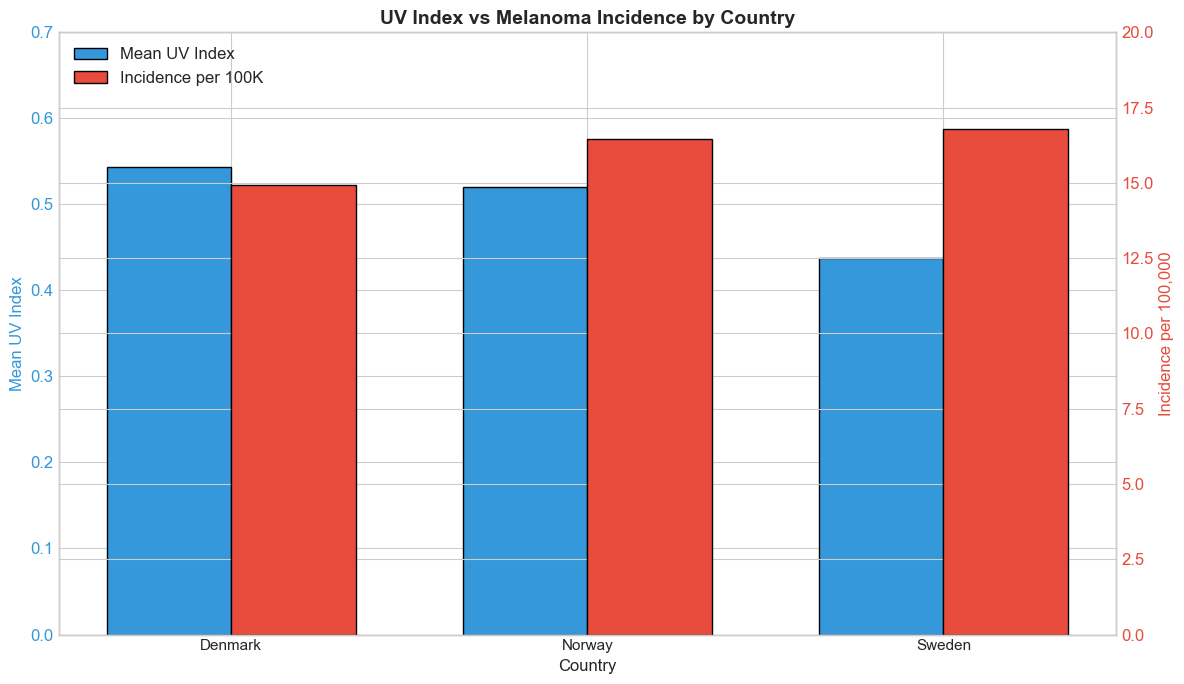

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 7))

x = np.arange(len(df['Country']))
width = 0.35

# UV Index bars
bars1 = ax1.bar(x - width/2, df['ALLSKY_SFC_UV_INDEX_mean'], width, 
                label='Mean UV Index', color='#3498DB', edgecolor='black')
ax1.set_ylabel('Mean UV Index', color='#3498DB', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3498DB')
ax1.set_ylim(0, 0.7)

# Create second y-axis
ax2 = ax1.twinx()

# Incidence bars
bars2 = ax2.bar(x + width/2, df['Incidence_Per_100K'], width, 
                label='Incidence per 100K', color='#E74C3C', edgecolor='black')
ax2.set_ylabel('Incidence per 100,000', color='#E74C3C', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#E74C3C')
ax2.set_ylim(0, 20)

# Labels
ax1.set_xlabel('Country', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df['Country'], fontsize=11)
ax1.set_title('UV Index vs Melanoma Incidence by Country', fontsize=14, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('plots/dual_axis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

Based on the analysis of Denmark, Norway, and Sweden:

1. **UV Index Ranking**: Denmark > Norway > Sweden
2. **Cancer Incidence Ranking**: Sweden > Norway > Denmark

**Key Finding**: The data shows a **negative correlation** between mean UV index and cancer incidence per 100,000 in these three Scandinavian countries. This suggests that in this specific dataset, higher UV exposure does NOT directly correlate with higher melanoma incidence.

**Important Caveats**:
- This is a small sample size (only 3 countries)
- Many confounding factors exist (skin type, sun protection behaviors, healthcare access, etc.)
- Historical UV exposure patterns may differ from current measurements
- Population genetics and lifestyle factors play significant roles